Network loaded: 1680 nodes, 2681 edges


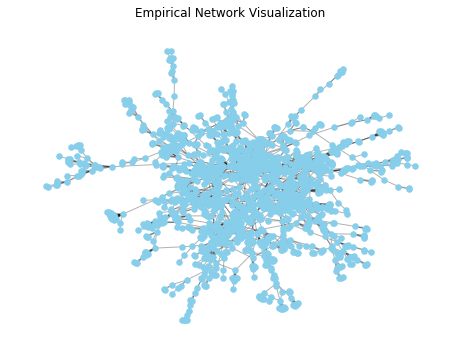

,Degree,Betweenness,Closeness,Eigenvector
0,0.000596,0.000000,0.094923,2.226560e-07
1,0.001191,0.000000,0.125834,1.701152e-02
2,0.010721,0.061059,0.133127,1.945778e-02
3,0.001191,0.007449,0.141378,1.442316e-02
4,0.000596,0.000000,0.087576,1.128572e-06


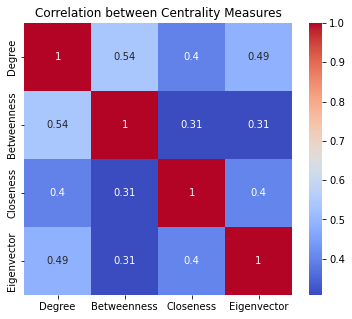

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# STEP 1: Load your empirical network
file_path = "gc_26.gml"   # make sure this file is in same folder as your notebook
G = nx.read_gml(file_path, label="id")

print(f"Network loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# STEP 2: Visualize
plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=30, node_color="skyblue")
nx.draw_networkx_edges(G, pos, alpha=0.3)
plt.title("Empirical Network Visualization")
plt.axis("off")
plt.show()

# STEP 3: Compute centralities
centralities = {
    "Degree": nx.degree_centrality(G),
    "Betweenness": nx.betweenness_centrality(G, normalized=True),
    "Closeness": nx.closeness_centrality(G),
    "Eigenvector": nx.eigenvector_centrality(G, max_iter=500)
}

# Convert to DataFrame
df_centrality = pd.DataFrame(centralities)
display(df_centrality.head())

# STEP 4: Correlation between measures
plt.figure(figsize=(6,5))
sns.heatmap(df_centrality.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation between Centrality Measures")
plt.show()


In [3]:
import numpy as np
import pandas as pd
import networkx as nx

n = G.number_of_nodes()
m = int(G.number_of_edges() / n)
n_sim = 5   # keep small for speed

random_deg, random_bet, random_clo, random_eig = [], [], [], []

for _ in range(n_sim):
    R = nx.gnm_random_graph(n, G.number_of_edges())
    random_deg.append(np.mean(list(nx.degree_centrality(R).values())))
    random_bet.append(np.mean(list(nx.betweenness_centrality(R, k=20).values())))  # approximate
    random_clo.append(np.mean(list(nx.closeness_centrality(R).values())))
    random_eig.append(np.mean(list(nx.eigenvector_centrality(R, max_iter=300).values())))

avg_random = {
    "Degree": np.mean(random_deg),
    "Betweenness": np.mean(random_bet),
    "Closeness": np.mean(random_clo),
    "Eigenvector": np.mean(random_eig)
}

BA = nx.barabasi_albert_graph(n, m)
ba_centralities = {
    "Degree": np.mean(list(nx.degree_centrality(BA).values())),
    "Betweenness": np.mean(list(nx.betweenness_centrality(BA, k=20).values())),
    "Closeness": np.mean(list(nx.closeness_centrality(BA).values())),
    "Eigenvector": np.mean(list(nx.eigenvector_centrality(BA, max_iter=300).values()))
}

avg_empirical = {
    "Degree": df_centrality["Degree"].mean(),
    "Betweenness": df_centrality["Betweenness"].mean(),
    "Closeness": df_centrality["Closeness"].mean(),
    "Eigenvector": df_centrality["Eigenvector"].mean()
}

comparison = pd.DataFrame([avg_empirical, avg_random, ba_centralities],
                          index=["Empirical Network", "Random Graphs (avg)", "Barabasi-Albert"])
display(comparison)


,Degree,Betweenness,Closeness,Eigenvector
Empirical Network,0.001901,0.005864,0.096297,0.004391
Random Graphs (avg),0.001901,0.002991,0.143629,0.017808
Barabasi-Albert,0.001190,0.004607,0.120099,0.004750


  Created wheel for python-louvain: filename=python_louvain-0.16-py3-none-any.whl size=9407 sha256=771ee1e55779e47dc6c10c2a57600f78da633b8253bad30d83e22b313ed88fae
  Stored in directory: c:\users\saumya\appdata\local\pip\cache\wheels\4d\7c\b6\79b198e4ec43f915fbdf967953d48b89a18893b12aa9df0ae2
Successfully built python-louvain
Number of communities detected: 38
Modularity of partition: 0.9194775674928536


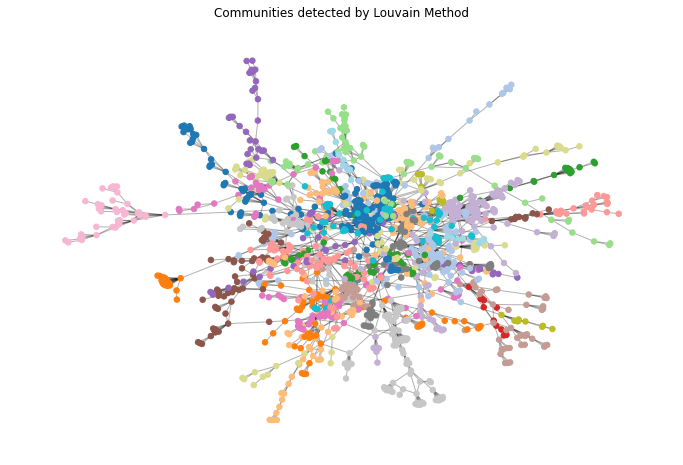

In [6]:
!pip install python-louvain

import networkx as nx
import community  # python-louvain
import matplotlib.pyplot as plt

# --- Louvain Community Detection ---
partition = community.best_partition(G)

# Number of communities
num_communities = len(set(partition.values()))
print("Number of communities detected:", num_communities)

# Modularity (measure of community strength)
modularity = community.modularity(partition, G)
print("Modularity of partition:", modularity)

# --- Visualize Communities (optional, can skip if slow) ---
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)  # layout

# Color nodes by community
colors = [partition[node] for node in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=30, node_color=colors, cmap=plt.cm.tab20)
nx.draw_networkx_edges(G, pos, alpha=0.3)
plt.title("Communities detected by Louvain Method")
plt.axis("off")
plt.show()


C:\Users\saumya\AppData\Local\Temp/ipykernel_15044/313108376.py:60: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  "Random": random.sample(G.nodes(), n_vacc),


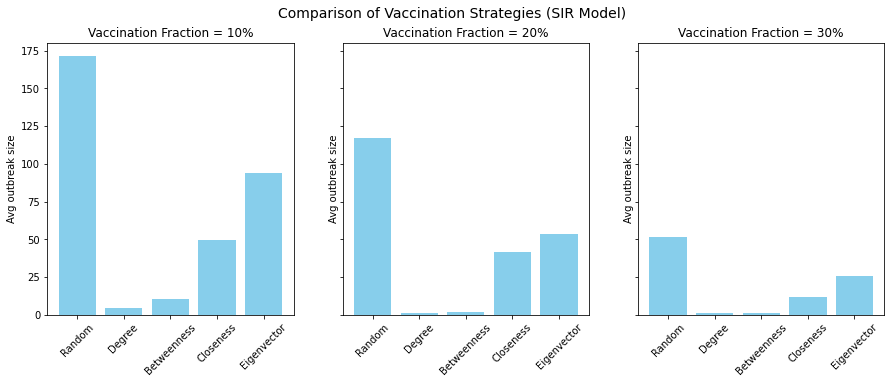


Vaccination Fraction = 10%
Random: 171.65
Degree: 4.45
Betweenness: 10.40
Closeness: 49.50
Eigenvector: 94.15

Vaccination Fraction = 20%
Random: 116.85
Degree: 1.30
Betweenness: 1.60
Closeness: 41.40
Eigenvector: 53.50

Vaccination Fraction = 30%
Random: 51.55
Degree: 0.75
Betweenness: 1.10
Closeness: 11.40
Eigenvector: 25.50


In [10]:
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt

# ---- PARAMETERS ----
beta = 0.05      # infection probability
gamma = 0.02     # recovery probability
vacc_fracs = [0.1, 0.2, 0.3]  # vaccination fractions
n_runs = 20      # repeat simulations to average results


# ---- SIR SIMULATION ----
def run_sir(G, beta, gamma, vaccinated_nodes, n_runs=10):
    outbreak_sizes = []
    
    for _ in range(n_runs):
        status = {node: "S" for node in G.nodes()}
        vaccinated_set = set(vaccinated_nodes)

        # Vaccinate nodes
        for v in vaccinated_nodes:
            status[v] = "R"
        
        # Patient zero
        patient_zero = random.choice(list(G.nodes()))
        if status[patient_zero] == "S":
            status[patient_zero] = "I"
        
        while "I" in status.values():
            new_status = status.copy()
            for node in G.nodes():
                if status[node] == "I":
                    for neighbor in G.neighbors(node):
                        if status[neighbor] == "S" and random.random() < beta:
                            new_status[neighbor] = "I"
                    if random.random() < gamma:
                        new_status[node] = "R"
            status = new_status

        # Count only infected-recovered (exclude vaccinated)
        infected_recovered = sum(1 for node, s in status.items() if s == "R" and node not in vaccinated_set)
        outbreak_sizes.append(infected_recovered)
    
    return np.mean(outbreak_sizes)

# ---- RUN MULTIPLE STRATEGIES ----
results = {f: {} for f in vacc_fracs}

for frac in vacc_fracs:
    n_vacc = int(frac * G.number_of_nodes())

    # Centralities
    deg_cent = nx.degree_centrality(G)
    bet_cent = nx.betweenness_centrality(G)
    clo_cent = nx.closeness_centrality(G)
    eig_cent = nx.eigenvector_centrality(G, max_iter=500)
    
    strategies = {
        "Random": random.sample(G.nodes(), n_vacc),
        "Degree": sorted(deg_cent, key=deg_cent.get, reverse=True)[:n_vacc],
        "Betweenness": sorted(bet_cent, key=bet_cent.get, reverse=True)[:n_vacc],
        "Closeness": sorted(clo_cent, key=clo_cent.get, reverse=True)[:n_vacc],
        "Eigenvector": sorted(eig_cent, key=eig_cent.get, reverse=True)[:n_vacc]
    }
    
    # Run SIR for each strategy
    for strat, nodes in strategies.items():
        results[frac][strat] = run_sir(G, beta, gamma, nodes, n_runs)


# ---- PLOT RESULTS ----
fig, axes = plt.subplots(1, len(vacc_fracs), figsize=(15, 5), sharey=True)

for i, frac in enumerate(vacc_fracs):
    axes[i].bar(results[frac].keys(), results[frac].values(), color="skyblue")
    axes[i].set_title(f"Vaccination Fraction = {int(frac*100)}%")
    axes[i].set_ylabel("Avg outbreak size")
    axes[i].tick_params(axis="x", rotation=45)

plt.suptitle("Comparison of Vaccination Strategies (SIR Model)", fontsize=14)
plt.show()

# Print detailed results
for frac in vacc_fracs:
    print(f"\nVaccination Fraction = {int(frac*100)}%")
    for strat, val in results[frac].items():
        print(f"{strat}: {val:.2f}")
